In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

In [3]:

X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
y_test  = pd.read_csv('../data/y_test.csv').values.ravel()

# model 1 : LogisticRegression

In [4]:
lr_model = LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42)


In [5]:
lr_model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [6]:
lr_train_pred =lr_model.predict(X_train)
lr_train_pred

array([1, 1, 0, ..., 1, 0, 0], shape=(5634,))

In [7]:
lr_test_pred = lr_model.predict(X_test)
lr_test_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [8]:
lr_probs = lr_model.predict_proba(X_test)[:, 1]
lr_probs

array([0.11740549, 0.85125685, 0.15269625, ..., 0.34060129, 0.01338496,
       0.01804723], shape=(1409,))

In [9]:
print(classification_report(y_test, lr_test_pred, target_names=['Stayed', 'Churned']))

              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1035
     Churned       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [10]:
print(f"AUC-ROC: {roc_auc_score(y_test, lr_probs):.4f}")

AUC-ROC: 0.8419


# model 2 : Randomforest

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

In [12]:
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

In [13]:
print(classification_report(y_test, rf_preds, target_names=['Stayed', 'Churned']))
print(f"AUC-ROC: {roc_auc_score(y_test, rf_probs):.4f}")

              precision    recall  f1-score   support

      Stayed       0.83      0.89      0.86      1035
     Churned       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409

AUC-ROC: 0.8219


# model 3 : xg boost

In [14]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=2.7, 
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

In [15]:
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:58:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [16]:
print(classification_report(y_test, xgb_preds, target_names=['Stayed', 'Churned']))
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_probs):.4f}")

              precision    recall  f1-score   support

      Stayed       0.91      0.73      0.81      1035
     Churned       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

AUC-ROC: 0.8451


# Model Comparison

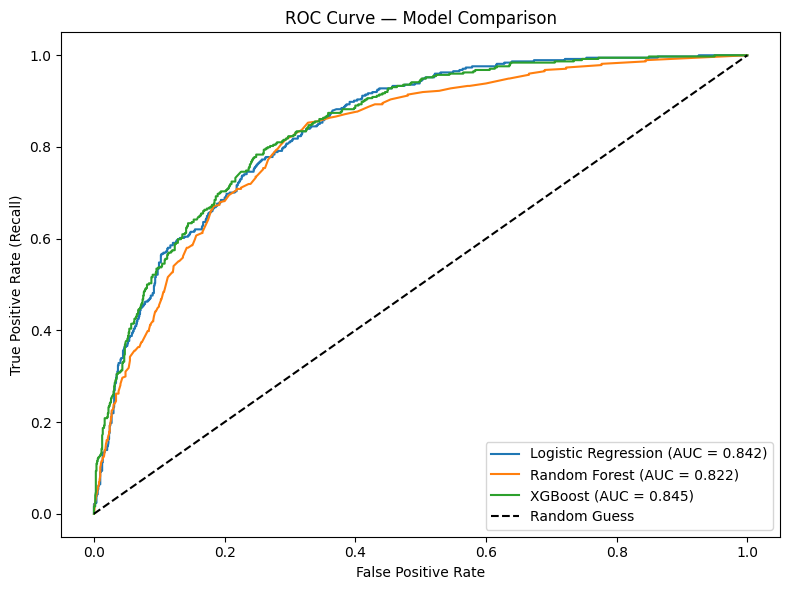

In [17]:
plt.figure(figsize=(8, 6))

for name, probs in [('Logistic Regression', lr_probs), 
                    ('Random Forest', rf_probs), 
                    ('XGBoost', xgb_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('../data/roc_curve.png')
plt.show()

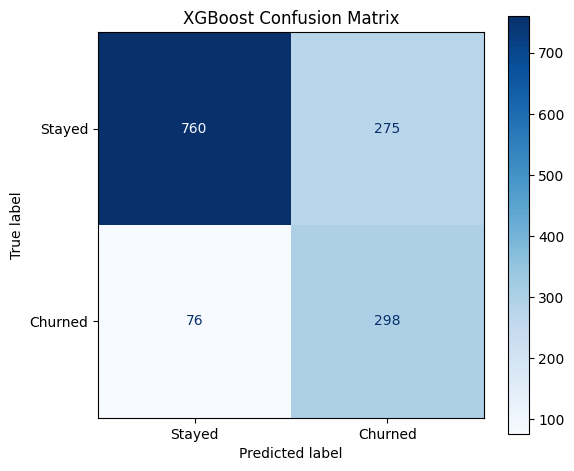

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, xgb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Stayed', 'Churned'])
disp.plot(ax=ax, cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png')
plt.show()

In [19]:
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted stayed): {tn}")
print(f"False Positives (predicted churn, actually stayed): {fp}")
print(f"False Negatives (missed churners): {fn}") 
print(f"True Positives (correctly caught churners): {tp}")

True Negatives (correctly predicted stayed): 760
False Positives (predicted churn, actually stayed): 275
False Negatives (missed churners): 76
True Positives (correctly caught churners): 298


In [20]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)



c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


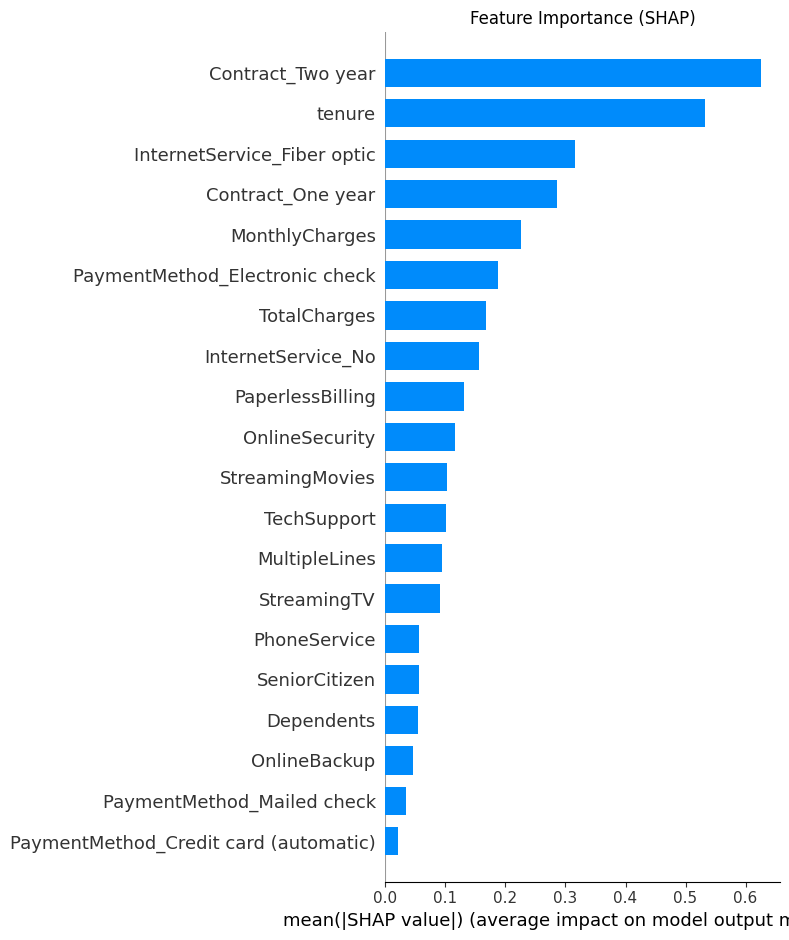

In [21]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig('../data/shap_importance.png')
plt.show()

# Impact direction (red = increases churn, blue = decreases churn)

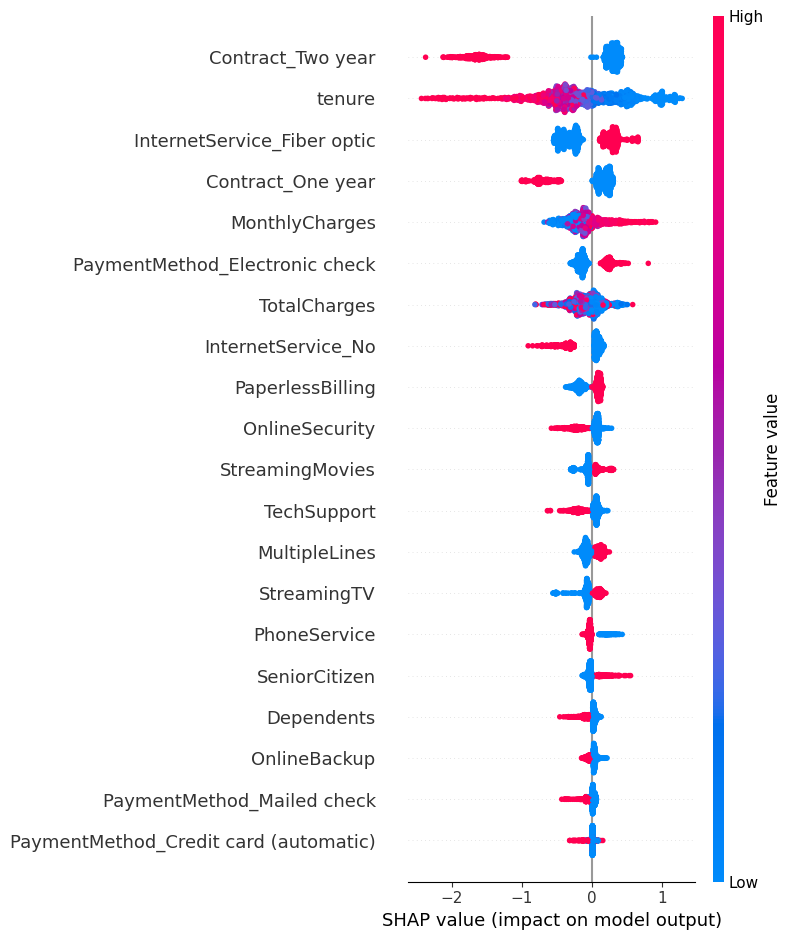

In [22]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../data/shap_beeswarm.png')
plt.show()

# conclusion:

1. Long-term contracts improve customer retention.

2. newer customers are more likely to churn

3. long-term customers are more loyal

4. customers using fiber optic internet are more likely to churn.

    Possible reasons:

        higher pricing

        service expectations

        customer dissatisfaction

    The company should investigate fiber optic customer satisfaction.

5. The model shows that customer churn is mainly influenced by contract type, tenure, monthly charges, internet service type, and support-related services.

Customers with short tenure, high monthly charges, fiber optic internet, and electronic check payments are more likely to churn.

On the other hand, customers with long-term contracts, online security, and tech support are less likely to churn.



In [23]:
joblib.dump(xgb_model, '../app/model.pkl')

['../app/model.pkl']

In [24]:
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, '../app/feature_names.pkl')

['../app/feature_names.pkl']